**Author:** Christopher Millward<br>
**Date:** August 14, 2026

The purpose of this notebook is to develop the function to visualize the heatmap distributions. 

---

Steps:
1. Write logic to plot one heatmap
2. Visualize all participants in one subplot
3. Build function to plot the avg 

In [1]:
import os 
import sys

# set root folder to project root
root_path = os.path.abspath(os.path.join(".."))
if root_path not in sys.path:
    sys.path.insert(0, root_path)

# auto reload
%load_ext autoreload
%autoreload 2

## 1. Write logic to plot one heatmap

In [2]:
import pickle
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib import cm
import numpy as np

from config import RESULTS_PICKLE_PATH
from schema import ParticipantDetails, Heatmap

In [9]:
# import pickle file
with open(Path(RESULTS_PICKLE_PATH), 'rb') as f:
    results: list[ParticipantDetails] = pickle.load(f)

participant = results[0]
heatmap: Heatmap = participant.left.humerothoracic.heatmap

In [17]:
print(f"Heatmap shape: {heatmap.shape}")
print(f"elevation shape: {heatmap.elevation.shape}")

Heatmap shape: (9, 18)
elevation shape: (162,)


Heatmap shape: (9, 18)
Bin width: 20°
Elevation boundaries: [  0  20  40  60  80 100 120 140 160 180]
POE boundaries: [  0  20  40  60  80 100 120 140 160 180 200 220 240 260 280 300 320 340
 360]


IndexError: index 4 is out of bounds for axis 0 with size 4

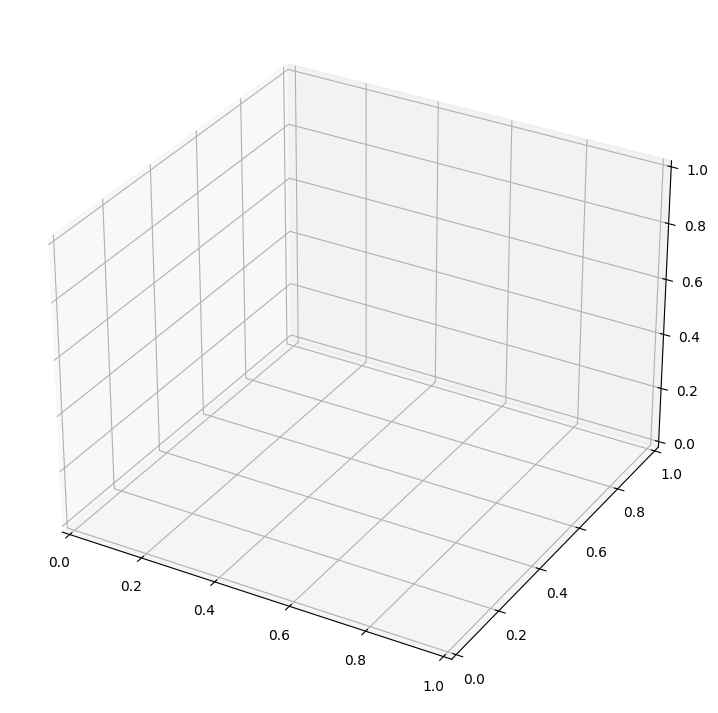

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize


# ---------------------------------------------------------------------
# Data
# ---------------------------------------------------------------------

data = heatmap.elevation

# Check the expected dimensions
n_elevation, n_poe = heatmap.shape

print(f"Heatmap shape: {heatmap.shape}")
print(f"Bin width: {heatmap.bin_width}°")


# ---------------------------------------------------------------------
# Create bin boundaries
# ---------------------------------------------------------------------

elevation_bounds = np.arange(
    0,
    heatmap.elevation_range_end + heatmap.bin_width,
    heatmap.bin_width,
)

poe_bounds = np.arange(
    0,
    heatmap.poe_range_end + heatmap.bin_width,
    heatmap.bin_width,
)

print(f"Elevation boundaries: {elevation_bounds}")
print(f"POE boundaries: {poe_bounds}")


# ---------------------------------------------------------------------
# Convert spherical coordinates to radians
# ---------------------------------------------------------------------

theta = elevation_bounds
phi = poe_bounds


# ---------------------------------------------------------------------
# Create spherical coordinate grid
# ---------------------------------------------------------------------

phi_grid, theta_grid = np.meshgrid(phi, theta)


# ---------------------------------------------------------------------
# Convert spherical coordinates to Cartesian coordinates
# ---------------------------------------------------------------------

X = np.sin(theta_grid) * np.cos(phi_grid)
Y = np.sin(theta_grid) * np.sin(phi_grid)
Z = np.cos(theta_grid)


# ---------------------------------------------------------------------
# Create colours from elevation data
# ---------------------------------------------------------------------

norm = Normalize(
    vmin=float(np.nanmin(data)),
    vmax=float(np.nanmax(data)),
)

colors = plt.get_cmap("viridis")(norm(data))


# ---------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------

fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(
    X,
    Y,
    Z,
    facecolors=colors,
    rstride=1,
    cstride=1,
    linewidth=0,
    antialiased=False,
    shade=False,
)


# ---------------------------------------------------------------------
# Colourbar
# ---------------------------------------------------------------------

# sm = cm.ScalarMappable(
#     norm=norm,
#     cmap="viridis",
# )

# sm.set_array(data)

# cbar = fig.colorbar(
#     sm,
#     ax=ax,
#     shrink=0.7,
#     pad=0.1,
# )

# cbar.set_label("Cumulative elevation motion (°)")


# ---------------------------------------------------------------------
# Formatting
# ---------------------------------------------------------------------

# ax.set_box_aspect((1, 1, 1))
# ax.set_axis_off()

# ax.view_init(
#     elev=25,
#     azim=-45,
# )

# ax.set_title("Cumulative Elevation Motion")

# plt.tight_layout()
# plt.show()